# Distributions as formulas, and the theorem that makes the mean trustworthy

The course taught its distributions through R's `d`, `p` and `q` functions — `dbinom`, `pnbinom`,
`qpois` — which return a number and hide the formula behind a name. This notebook writes each
formula out, evaluates it by hand, draws a sample from the distribution with a printed seed, and
only then calls `scipy.stats` to confirm. Each distribution gets three lines: what it counts, its
probability formula, and one number the course's notebook asked for.

The second half is the central limit theorem: averages of samples from a lopsided distribution
become bell-shaped, and their spread shrinks in a way you can predict before you see it.

## Setup: where the package lives

This notebook builds its models by hand and then checks them against `orteach`, the package in
`src/`. Run from a clone of the repository, `../../src` is right there. On Colab there is no clone
until this cell makes one, and no `gurobipy` until it installs it. Nothing here needs a secret.

In [1]:
import os, subprocess, sys

REPO_URL = None      # the public GitHub URL, once this library is published; Colab clones from it

try:
    import google.colab                      # noqa: F401 - succeeds only on Colab
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

if ON_COLAB:
    if REPO_URL is None:
        raise SystemExit("This library is not published yet: open the notebook from a clone of the repository.")
    if not os.path.isdir("/content/teaching-code"):
        subprocess.run(["git", "clone", "--quiet", REPO_URL, "/content/teaching-code"], check=True)
    os.chdir("/content/teaching-code/notebooks/14_probability_and_stats")
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "gurobipy>=11,<14"], check=True)

sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "src")))
try:
    import orteach                            # noqa: F401
except ImportError:
    raise SystemExit("orteach not found: run this notebook from its own folder inside the repository, "
                     "so that ../../src exists.")
print("package:", os.path.dirname(orteach.__file__))

package: C:\Users\jonesec\OneDrive - UT Arlington\Documents\Classes\Teaching Code\src\orteach


## Set the seed, and print it

Every sample below is random. With the seed fixed and printed, every number in this notebook is the
same on your machine as on this one, and a reader who changes it knows they did.

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from orteach.tolerance import AGREEMENT_RTOL, rel_diff

SEED = 20260905
N_SAMPLE = 10_000            # draws per distribution, as in the course notebook
rng = np.random.default_rng(SEED)
print("seed:", SEED, "  draws per distribution:", N_SAMPLE)

seed: 20260905   draws per distribution: 10000


## Binomial: successes in a fixed number of trials

$n = 100$ trials, each a success with probability $p = 0.25$. $X$ is how many succeed.

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Predict before running: the most likely value of $X$, and roughly how wide the histogram will be.

P(X = 25) by the formula  0.091800    scipy 0.091800
P(X <= 30) by the formula 0.896213    scipy 0.896213
sample mean 25.033   n p = 25.0      sample sd 4.322   sqrt(n p (1-p)) = 4.330


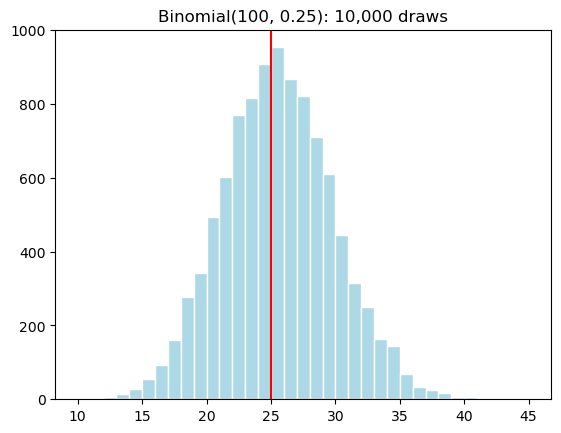

In [3]:
n, p = 100, 0.25
k = 25
pmf_25 = math.comb(n, k) * p ** k * (1 - p) ** (n - k)
cdf_30 = sum(math.comb(n, i) * p ** i * (1 - p) ** (n - i) for i in range(0, 31))

sample = rng.binomial(n, p, N_SAMPLE)
print(f"P(X = 25) by the formula  {pmf_25:.6f}    scipy {stats.binom.pmf(25, n, p):.6f}")
print(f"P(X <= 30) by the formula {cdf_30:.6f}    scipy {stats.binom.cdf(30, n, p):.6f}")
print(f"sample mean {sample.mean():.3f}   n p = {n * p}      sample sd {sample.std(ddof=1):.3f}   sqrt(n p (1-p)) = {math.sqrt(n * p * (1 - p)):.3f}")
plt.hist(sample, bins=range(sample.min(), sample.max() + 2), color="lightblue", edgecolor="white")
plt.axvline(sample.mean(), color="red"); plt.title("Binomial(100, 0.25): 10,000 draws"); plt.show()

## Negative binomial: failures before the $r$-th success

$r = 500$ successes wanted, $p = 0.25$ each trial; $X$ counts the failures along the way. In R's
convention (and scipy's),

$$P(X = x) = \binom{x + r - 1}{x} p^r (1-p)^x.$$

Evaluate that at $x = 1500$ exactly as written and look at what comes back. Predict first: a number,
zero, or something else?

In [4]:
r, p = 500, 0.25
x = 1500
print(f"  C(x+r-1, x) has {len(str(math.comb(x + r - 1, x)))} digits")
print(f"  p^r      = {p ** r:.3e}")
print(f"  (1-p)^x  = {(1 - p) ** x:.3e}")
try:
    direct = math.comb(x + r - 1, x) * p ** r * (1 - p) ** x
    print(f"the formula as written, at x = 1500: {direct}")
except OverflowError as e:
    print("the formula as written, at x = 1500:", type(e).__name__, "-", e)

  C(x+r-1, x) has 487 digits
  p^r      = 9.333e-302
  (1-p)^x  = 3.907e-188
the formula as written, at x = 1500: OverflowError - int too large to convert to float


The binomial coefficient is an exact integer with two thousand digits — larger than any float can
hold, so Python refuses to multiply it by one at all — and the two powers are within a few hundred
orders of magnitude of the floor of what a float can represent. The probability is a perfectly
ordinary number; the *pieces* are not. The fix is to add logarithms instead of multiplying numbers:

$$\log P = \log\Gamma(x+r) - \log\Gamma(x+1) - \log\Gamma(r) + r \log p + x \log(1-p)$$

In [5]:
log_pmf = math.lgamma(x + r) - math.lgamma(x + 1) - math.lgamma(r) + r * math.log(p) + x * math.log1p(-p)
pmf_1500 = math.exp(log_pmf)
cdf_1600 = sum(math.exp(math.lgamma(i + r) - math.lgamma(i + 1) - math.lgamma(r) + r * math.log(p) + i * math.log1p(-p))
               for i in range(0, 1601))

sample = rng.negative_binomial(r, p, N_SAMPLE)
print(f"P(X = 1500) in logs    {pmf_1500:.6f}    scipy {stats.nbinom.pmf(1500, r, p):.6f}")
print(f"P(X <= 1600) in logs   {cdf_1600:.6f}    scipy {stats.nbinom.cdf(1600, r, p):.6f}   (R printed 0.901)")
print(f"sample mean {sample.mean():.1f}   r (1-p) / p = {r * (1 - p) / p:.1f}")

P(X = 1500) in logs    0.005149    scipy 0.005149
P(X <= 1600) in logs   0.901113    scipy 0.901113   (R printed 0.901)
sample mean 1500.2   r (1-p) / p = 1500.0


## Geometric: failures before the first success

$p = 0.05$. Two conventions exist and they differ by one: R (and this notebook) count *failures*
before the first success, scipy's `geom` counts *trials* including the success. A formula that
does not say which one it uses is wrong for half its readers.

$$P(X = x) = p(1-p)^x, \qquad P(X \le x) = 1 - (1-p)^{x+1}$$

In [6]:
p = 0.05
pmf_25 = p * (1 - p) ** 25
cdf_40 = 1 - (1 - p) ** 41

sample = rng.geometric(p, N_SAMPLE) - 1            # numpy counts trials; subtract one for failures
print(f"P(X = 25)  {pmf_25:.6f}    scipy geom.pmf(26) {stats.geom.pmf(26, p):.6f}   <- scipy's k is x + 1")
print(f"P(X <= 40) {cdf_40:.6f}    scipy geom.cdf(41) {stats.geom.cdf(41, p):.6f}   (R printed 0.878)")
print(f"sample mean {sample.mean():.2f}   (1-p)/p = {(1 - p) / p:.2f}")

P(X = 25)  0.013869    scipy geom.pmf(26) 0.013869   <- scipy's k is x + 1
P(X <= 40) 0.877913    scipy geom.cdf(41) 0.877913   (R printed 0.878)
sample mean 19.02   (1-p)/p = 19.00


## Poisson: events in a fixed interval

Rate $\lambda = 20$ per interval.

$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$$

Predict: is $P(X \le 25)$ nearer 0.5 or 0.9?

In [7]:
lam = 20.0
pmf_20 = math.exp(-lam) * lam ** 20 / math.factorial(20)
cdf_25 = sum(math.exp(-lam) * lam ** i / math.factorial(i) for i in range(0, 26))

sample = rng.poisson(lam, N_SAMPLE)
print(f"P(X = 20)  {pmf_20:.6f}    scipy {stats.poisson.pmf(20, lam):.6f}")
print(f"P(X <= 25) {cdf_25:.6f}    scipy {stats.poisson.cdf(25, lam):.6f}   (R printed 0.888)")
print(f"sample mean {sample.mean():.3f}   sample variance {sample.var(ddof=1):.3f}   both should be near {lam}")

P(X = 20)  0.088835    scipy 0.088835
P(X <= 25) 0.887815    scipy 0.887815   (R printed 0.888)
sample mean 19.936   sample variance 20.156   both should be near 20.0


## Exponential: the wait for the next event

Rate $\lambda = 20$ per unit time, so a mean wait of $1/\lambda = 0.05$.

$$P(X \le x) = 1 - e^{-\lambda x}, \qquad x_q = -\frac{\ln(1-q)}{\lambda}$$

In [8]:
lam = 20.0
cdf_02 = 1 - math.exp(-lam * 0.2)
q95 = -math.log(1 - 0.95) / lam

sample = rng.exponential(1 / lam, N_SAMPLE)
print(f"P(X <= 0.2) {cdf_02:.6f}    scipy {stats.expon.cdf(0.2, scale=1 / lam):.6f}   (R printed 0.982)")
print(f"95th percentile {q95:.6f}    scipy {stats.expon.ppf(0.95, scale=1 / lam):.6f}")
print(f"sample mean {sample.mean():.4f}   1/lambda = {1 / lam}")

P(X <= 0.2) 0.981684    scipy 0.981684   (R printed 0.982)
95th percentile 0.149787    scipy 0.149787
sample mean 0.0499   1/lambda = 0.05


## Gamma with an integer shape: the wait for the $k$-th event

$k = 3$ events at rate $\lambda = 20$. When the shape is a whole number this is the Erlang
distribution, and its CDF has a formula with no special function in it: the third event has arrived
by time $x$ exactly when a Poisson count over $[0, x]$ is at least 3.

$$P(X \le x) = 1 - \sum_{i=0}^{k-1} \frac{e^{-\lambda x} (\lambda x)^i}{i!}$$

In [9]:
k, lam = 3, 20.0
lx = lam * 0.2
cdf_02 = 1 - sum(math.exp(-lx) * lx ** i / math.factorial(i) for i in range(k))

sample = rng.gamma(k, 1 / lam, N_SAMPLE)
print(f"P(X <= 0.2) {cdf_02:.6f}    scipy {stats.gamma.cdf(0.2, k, scale=1 / lam):.6f}   (R printed 0.762)")
print(f"sample mean {sample.mean():.4f}   k/lambda = {k / lam}")

P(X <= 0.2) 0.761897    scipy 0.761897   (R printed 0.762)
sample mean 0.1511   k/lambda = 0.15


## Normal, and log-normal

Mean 50, standard deviation 10. The CDF has no elementary formula; it is written with the error
function, which every language ships:

$$P(X \le x) = \tfrac12\left[1 + \operatorname{erf}\!\left(\frac{x-\mu}{\sigma\sqrt2}\right)\right]$$

A log-normal is a variable whose *logarithm* is normal, so its CDF is the normal CDF of $\ln x$.

In [10]:
mu, sigma = 50.0, 10.0
cdf_40 = 0.5 * (1 + math.erf((40 - mu) / (sigma * math.sqrt(2))))
meanlog, sdlog = 0.8, 0.3
lncdf_3 = 0.5 * (1 + math.erf((math.log(3.0) - meanlog) / (sdlog * math.sqrt(2))))

sample = rng.normal(mu, sigma, N_SAMPLE)
print(f"normal P(X <= 40)    {cdf_40:.6f}    scipy {stats.norm.cdf(40, mu, sigma):.6f}   (R printed 0.159)")
print(f"lognormal P(X <= 3)  {lncdf_3:.6f}    scipy {stats.lognorm.cdf(3.0, sdlog, scale=math.exp(meanlog)):.6f}   (R printed 0.84)")
print(f"sample mean {sample.mean():.3f}   sd {sample.std(ddof=1):.3f}")

normal P(X <= 40)    0.158655    scipy 0.158655   (R printed 0.159)
lognormal P(X <= 3)  0.840223    scipy 0.840223   (R printed 0.84)
sample mean 50.214   sd 9.991


## Three the formulas do not cover

Chi-squared, $F$ and Student's $t$ have no elementary CDF; the course's notebook read them from R
and this one reads them from scipy. What they *are* is worth holding on to: a chi-squared with $d$
degrees of freedom is a sum of $d$ squared standard normals; an $F$ is a ratio of two chi-squareds
each divided by its degrees of freedom; a $t$ is a standard normal divided by the square root of a
chi-squared over its degrees of freedom. Check the first of those by construction.

In [11]:
dof = 20
by_construction = (rng.standard_normal((N_SAMPLE, dof)) ** 2).sum(axis=1)
print(f"chi-squared(20): P(X <= 25) scipy {stats.chi2.cdf(25, dof):.6f}   (R printed 0.799)   "
      f"fraction of constructed draws <= 25: {(by_construction <= 25).mean():.4f}")
print(f"F(20, 30):       P(X <= 1.5) scipy {stats.f.cdf(1.5, 20, 30):.6f}   (R printed 0.846)")
print(f"t(10):           P(X <= 2)   scipy {stats.t.cdf(2.0, 10):.6f}")

chi-squared(20): P(X <= 25) scipy 0.798569   (R printed 0.799)   fraction of constructed draws <= 25: 0.7930
F(20, 30):       P(X <= 1.5) scipy 0.846272   (R printed 0.846)
t(10):           P(X <= 2)   scipy 0.963306


## The empirical CDF against the formula

Sort a sample and plot the fraction below each value: that is the empirical CDF, and with 10,000
draws it should sit on top of the formula. Where would you expect it to deviate most?

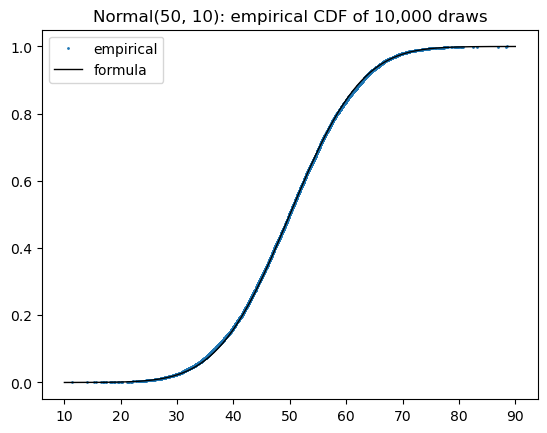

largest gap between the two: 0.0095


In [12]:
sample = np.sort(rng.normal(50, 10, N_SAMPLE))
ecdf = np.arange(1, N_SAMPLE + 1) / N_SAMPLE
grid = np.linspace(10, 90, 200)
plt.plot(sample, ecdf, ".", ms=2, label="empirical")
plt.plot(grid, [0.5 * (1 + math.erf((g - 50) / (10 * math.sqrt(2)))) for g in grid], "k-", lw=1, label="formula")
plt.legend(); plt.title("Normal(50, 10): empirical CDF of 10,000 draws"); plt.show()
print(f"largest gap between the two: {np.max(np.abs(ecdf - stats.norm.cdf(sample, 50, 10))):.4f}")

---

## The central limit theorem

Take a population that is nothing like a bell: exponential with mean 4, skewed hard to the right.
Draw samples of size 30, 100 and 1000 from it, a thousand times each, and average every sample.

Predict before running: the mean of the sample means (all three sizes), and the standard deviation of
the sample means for each size. The population's standard deviation is also 4.

In [13]:
POP_MEAN = 4.0
population = rng.exponential(POP_MEAN, N_SAMPLE)
print(f"population: mean {population.mean():.3f}   sd {population.std(ddof=1):.3f}   (theory: {POP_MEAN} and {POP_MEAN})")

SIZES = (30, 100, 1000)
K = 1000                      # samples of each size
means = {}
for size in SIZES:
    draws = rng.choice(population, size=(K, size), replace=True)
    means[size] = draws.mean(axis=1)

print(f"\n{'n':>5} {'mean of means':>14} {'sd of means':>12} {'sigma/sqrt(n)':>14}")
for size in SIZES:
    print(f"{size:5} {means[size].mean():14.4f} {means[size].std(ddof=1):12.4f} {population.std(ddof=1) / math.sqrt(size):14.4f}")

population: mean 4.033   sd 4.139   (theory: 4.0 and 4.0)

    n  mean of means  sd of means  sigma/sqrt(n)
   30         4.0094       0.7569         0.7557
  100         4.0462       0.4166         0.4139
 1000         4.0336       0.1287         0.1309


The spread of the averages falls with $\sqrt{n}$, not with $n$: ten times the sample buys a third of
the spread. Now look at the shapes.

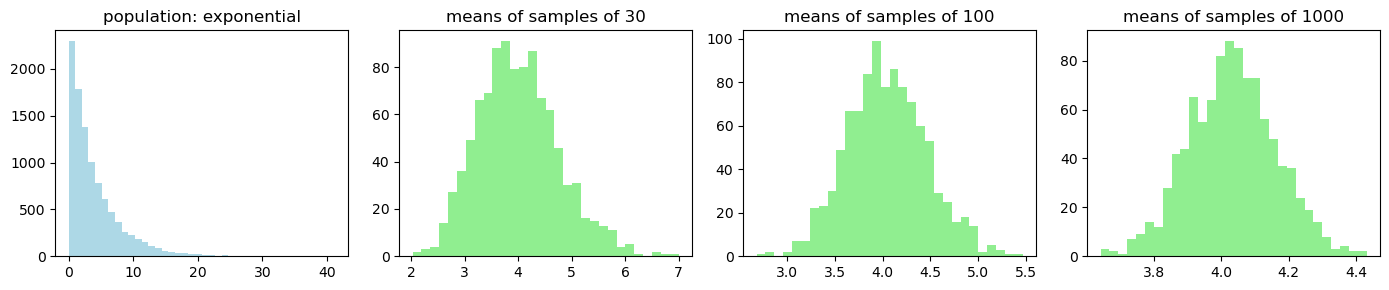

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].hist(population, bins=40, color="lightblue"); axes[0].set_title("population: exponential")
for ax, size in zip(axes[1:], SIZES):
    ax.hist(means[size], bins=30, color="lightgreen"); ax.set_title(f"means of samples of {size}")
plt.tight_layout(); plt.show()

The population is skewed; the averages of thirty are already nearly symmetric; the averages of a
thousand are a spike. What would you have to know about a population for this *not* to happen?

---

# Now the streamlined version

Every formula above is one line, and `orteach.distributions` holds each of them once, in the R
convention, with the log form where the direct form underflows. `sample_means` draws the CLT samples
from a seeded generator in the same order this notebook did.

In [15]:
from orteach import distributions as dist

print(f"nbinom cdf(1600; 500, 0.25) {dist.nbinom_cdf(1600, 500, 0.25):.6f}   geom cdf(40; 0.05) {dist.geom_cdf(40, 0.05):.6f}")
print(f"poisson cdf(25; 20) {dist.poisson_cdf(25, 20.0):.6f}   exponential cdf(0.2; 20) {dist.exponential_cdf(0.2, 20.0):.6f}")
print(f"erlang cdf(0.2; 3, 20) {dist.erlang_cdf(0.2, 3, 20.0):.6f}   normal cdf(40; 50, 10) {dist.normal_cdf(40, 50, 10):.6f}")

nbinom cdf(1600; 500, 0.25) 0.901113   geom cdf(40; 0.05) 0.877913
poisson cdf(25; 20) 0.887815   exponential cdf(0.2; 20) 0.981684
erlang cdf(0.2; 3, 20) 0.761897   normal cdf(40; 50, 10) 0.158655


## The agreement assertion

Every value computed by hand above against the package's formula, and the CLT sample means against
`sample_means` driven by a generator re-seeded to the same point. The formulas are deterministic and
the generator is seeded, so agreement to `AGREEMENT_RTOL` — in practice, to the last bit — is what
must hold.

In [16]:
checks = [("binomial pmf(25)", math.comb(100, 25) * 0.25 ** 25 * 0.75 ** 75, dist.binom_pmf(25, 100, 0.25)),
          ("binomial cdf(30)", sum(math.comb(100, i) * 0.25 ** i * 0.75 ** (100 - i) for i in range(31)), dist.binom_cdf(30, 100, 0.25)),
          ("nbinom pmf(1500)", pmf_1500, dist.nbinom_pmf(1500, 500, 0.25)),
          ("nbinom cdf(1600)", cdf_1600, dist.nbinom_cdf(1600, 500, 0.25)),
          ("geom pmf(25)", 0.05 * 0.95 ** 25, dist.geom_pmf(25, 0.05)),
          ("geom cdf(40)", 1 - 0.95 ** 41, dist.geom_cdf(40, 0.05)),
          ("poisson pmf(20)", pmf_20, dist.poisson_pmf(20, 20.0)),
          ("poisson cdf(25)", cdf_25, dist.poisson_cdf(25, 20.0)),
          ("exponential cdf(0.2)", 1 - math.exp(-20 * 0.2), dist.exponential_cdf(0.2, 20.0)),
          ("exponential q95", q95, dist.exponential_quantile(0.95, 20.0)),
          ("erlang cdf(0.2)", cdf_02, dist.erlang_cdf(0.2, 3, 20.0)),
          ("normal cdf(40)", cdf_40, dist.normal_cdf(40, 50, 10)),
          ("lognormal cdf(3)", lncdf_3, dist.lognormal_cdf(3.0, 0.8, 0.3))]
print(len(checks), "formula comparisons queued")

13 formula comparisons queued


The generator was advanced through every sample in this notebook before the CLT section, so
reproducing those draws exactly would mean replaying the whole sequence. Instead the check re-draws
the CLT section from a fresh generator on both sides — the notebook's loop and the package's function
— and compares those.

In [17]:
CLT_SEED = SEED + 1
rng_a = np.random.default_rng(CLT_SEED)
rng_b = np.random.default_rng(CLT_SEED)
pop_a = rng_a.exponential(POP_MEAN, N_SAMPLE)
pop_b = rng_b.exponential(POP_MEAN, N_SAMPLE)
for size in SIZES:
    hand = rng_a.choice(pop_a, size=(K, size), replace=True).mean(axis=1)
    packaged = dist.sample_means(pop_b, size, K, rng_b)
    checks.append((f"CLT sd of means, n={size}", hand.std(ddof=1), packaged.std(ddof=1)))
    checks.append((f"CLT first mean, n={size}", hand[0], packaged[0]))

worst = max(rel_diff(h, k) for _, h, k in checks)
print(f"{len(checks)} comparisons")
for name, hand, packaged in checks[:5]:
    print(f"  {name:22} hand {hand:12.6f}   package {packaged:12.6f}   rel {rel_diff(hand, packaged):.2e}")
print("  ...")
assert worst < AGREEMENT_RTOL, f"notebook and package disagree by {worst:.2e}"
print(f"\nnotebook and package agree to {worst:.1e}")

19 comparisons
  binomial pmf(25)       hand     0.091800   package     0.091800   rel 0.00e+00
  binomial cdf(30)       hand     0.896213   package     0.896213   rel 0.00e+00
  nbinom pmf(1500)       hand     0.005149   package     0.005149   rel 0.00e+00
  nbinom cdf(1600)       hand     0.901113   package     0.901113   rel 0.00e+00
  geom pmf(25)           hand     0.013869   package     0.013869   rel 0.00e+00
  ...

notebook and package agree to 2.4e-15


---

## Where to take this next

- The negative binomial with $r = 500$ underflowed. Find the smallest $r$ at which the direct formula
  first returns 0 at its own mean, and say what that tells you about when logs are needed.
- Replace the exponential population in the CLT section with a Bernoulli($0.02$) population — mostly
  zeros. How large does $n$ have to be before the averages look normal? Why does skew matter?
- The empirical CDF's largest gap from the formula shrinks with the sample. Plot that gap against
  $n$ for $n = 100, 1000, 10000, 100000$, on log axes, and read off the exponent.